    edges_version edge_from  edge_id  edge_numLanes  edge_priority  \
0             1.2     gneJ1   -gneE0              3             -1   
1             1.2     gneJ2   -gneE1              3             -1   
2             1.2    gneJ11  -gneE10              3             -1   
3             1.2    gneJ12  -gneE11              3             -1   
4             1.2    gneJ13  -gneE12              3             -1   
5             1.2    gneJ14  -gneE13              3             -1   
6             1.2    gneJ15  -gneE14              3             -1   
7             1.2    gneJ16  -gneE15              3             -1   
8             1.2    gneJ17  -gneE16              3             -1   
9             1.2    gneJ18  -gneE17              3             -1   
10            1.2    gneJ19  -gneE18              3             -1   
11            1.2     gneJ1  -gneE19              3             -1   
12            1.2     gneJ3   -gneE2              3             -1   
13            1.2   

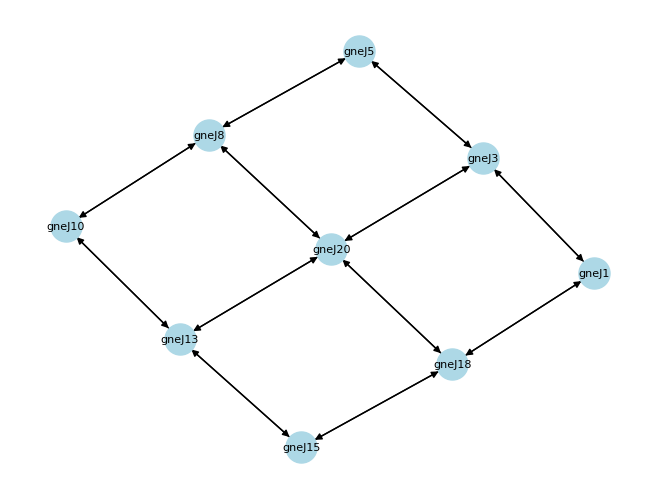

In [16]:
import networkx as nx
import pandas as pd

# Load the CSV data into a DataFrame
df = pd.read_csv("plain.edg.csv", delimiter=';')  # Replace "your_file.csv" with your actual file name
print(df)
# Create the directed graph (assuming one-way streets)
G = nx.DiGraph()  # Use nx.Graph() for undirected graph (two-way streets)

# Add edges with attributes
for _, row in df.iterrows():
    G.add_edge(
        row['edge_from'], 
        row['edge_to'],
    )
    G.add_node(row['edge_to']) 

for node in G.nodes():
    print(node)
    print(G.degree(node))
# Identify leaf nodes
leaf_nodes = [node for node in G.nodes() if G.degree(node) == 2]

# Remove leaf nodes
G.remove_nodes_from(leaf_nodes)

# Visualization (optional)
import matplotlib.pyplot as plt
# ...(positioning logic for better layout, if desired)
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_size=8)
plt.show()


In [15]:
import networkx as nx
import numpy as np

# Assuming you have your graph 'G' created already

# Get the edge matrix as a NumPy array
edge_matrix = nx.to_numpy_array(G)

# Print the edge matrix in a visually appealing format
print("Edge Matrix:")
print(edge_matrix)


Edge Matrix:
[[0. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 1. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1. 1. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0.]]


In [1]:
import torch

torch.manual_seed(1)
torch.cuda.manual_seed(1)
torch.cuda.manual_seed_all(1)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
from torch_geometric.datasets import Planetoid

# Import dataset from PyTorch Geometric
dataset = Planetoid(root=".", name="Cora")
data = dataset[0]


import torch
torch.manual_seed(1)
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, GCNConv
from torch.nn import Linear, Dropout

/home/nicolas/Desktop/MARL-GAT/MARL-GAT/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Processing...
Done!


In [3]:
dataset.num_features

1433

In [28]:
data.x.shape

torch.Size([2708, 1433])

In [12]:
unique_labels = torch.unique(data.y)

print(unique_labels)

unique_labels.tolist()

tensor([0, 1, 2, 3, 4, 5, 6])


[0, 1, 2, 3, 4, 5, 6]

In [17]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads=8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads=1)

    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.gat2(h, edge_index)
        return F.log_softmax(h, dim=1)

In [18]:
gat = GAT(dataset.num_features, 32, dataset.num_classes)

In [27]:
gat(data.x, data.edge_index).shape

torch.Size([2708, 7])

In [14]:
print(data.edge_index)

tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])


In [10]:
data.x.shape

torch.Size([2708, 1433])

In [31]:
import torch
import torch.nn as nn

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [32]:
data = sns.load_dataset("flights")
data.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [33]:
data.shape

(144, 3)

In [34]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 15
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size


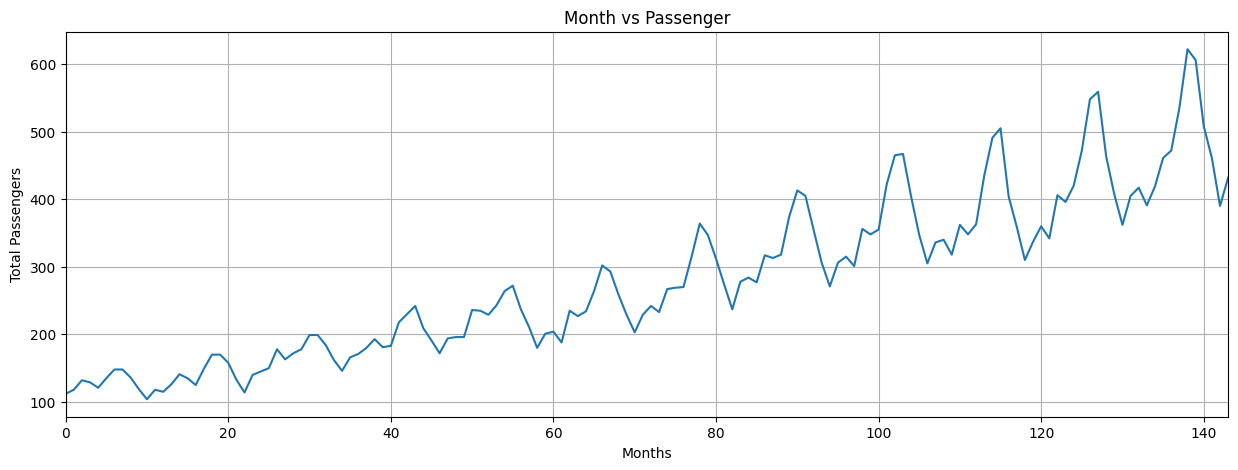

In [35]:
plt.title('Month vs Passenger')
plt.ylabel('Total Passengers')
plt.xlabel('Months')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(data['passengers'])

In [36]:
all_data = data['passengers'].values.astype(float)
all_data

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.])

In [37]:
test_data_size = 12

train_data = all_data[:-test_data_size]
test_data = all_data[-test_data_size:]



In [38]:
print(len(train_data))
print(len(test_data))



132
12


In [39]:


print(test_data)



[417. 391. 419. 461. 472. 535. 622. 606. 508. 461. 390. 432.]


In [40]:


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
train_data_normalized = scaler.fit_transform(train_data .reshape(-1, 1))



In [41]:


train_data_normalized = torch.FloatTensor(train_data_normalized).view(-1)



In [42]:


train_window = 12



In [47]:
train_data_normalized

tensor([-0.9648, -0.9385, -0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066,
        -0.8593, -0.9341, -1.0000, -0.9385, -0.9516, -0.9033, -0.8374, -0.8637,
        -0.9077, -0.8022, -0.7099, -0.7099, -0.7626, -0.8725, -0.9560, -0.8418,
        -0.8198, -0.7978, -0.6747, -0.7407, -0.7011, -0.6747, -0.5824, -0.5824,
        -0.6484, -0.7451, -0.8154, -0.7275, -0.7055, -0.6659, -0.6088, -0.6615,
        -0.6527, -0.4989, -0.4462, -0.3934, -0.5385, -0.6176, -0.7011, -0.6044,
        -0.5956, -0.5956, -0.4198, -0.4242, -0.4505, -0.3890, -0.2967, -0.2615,
        -0.4154, -0.5297, -0.6659, -0.5736, -0.5604, -0.6308, -0.4242, -0.4593,
        -0.4286, -0.2967, -0.1297, -0.1692, -0.3187, -0.4505, -0.5648, -0.4505,
        -0.3934, -0.4330, -0.2835, -0.2747, -0.2703, -0.0725,  0.1429,  0.0681,
        -0.0857, -0.2527, -0.4154, -0.2352, -0.2088, -0.2396, -0.0637, -0.0813,
        -0.0593,  0.1868,  0.3582,  0.3231,  0.1033, -0.1121, -0.2659, -0.1121,
        -0.0725, -0.1341,  0.1077,  0.07

In [43]:
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+tw:i+tw+1]
        inout_seq.append((train_seq ,train_label))
    return inout_seq



In [44]:

train_inout_seq = create_inout_sequences(train_data_normalized, train_window)



In [46]:
train_inout_seq

[(tensor([-0.9648, -0.9385, -0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066,
          -0.8593, -0.9341, -1.0000, -0.9385]),
  tensor([-0.9516])),
 (tensor([-0.9385, -0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066, -0.8593,
          -0.9341, -1.0000, -0.9385, -0.9516]),
  tensor([-0.9033])),
 (tensor([-0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066, -0.8593, -0.9341,
          -1.0000, -0.9385, -0.9516, -0.9033]),
  tensor([-0.8374])),
 (tensor([-0.8901, -0.9253, -0.8637, -0.8066, -0.8066, -0.8593, -0.9341, -1.0000,
          -0.9385, -0.9516, -0.9033, -0.8374]),
  tensor([-0.8637])),
 (tensor([-0.9253, -0.8637, -0.8066, -0.8066, -0.8593, -0.9341, -1.0000, -0.9385,
          -0.9516, -0.9033, -0.8374, -0.8637]),
  tensor([-0.9077])),
 (tensor([-0.8637, -0.8066, -0.8066, -0.8593, -0.9341, -1.0000, -0.9385, -0.9516,
          -0.9033, -0.8374, -0.8637, -0.9077]),
  tensor([-0.8022])),
 (tensor([-0.8066, -0.8066, -0.8593, -0.9341, -1.0000, -0.9385, -0.9516, -0.9033,
      

In [45]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size

        self.lstm = nn.LSTM(input_size, hidden_layer_size)

        self.linear = nn.Linear(hidden_layer_size, output_size)

        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq) ,1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

In [48]:
model = LSTM()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [49]:
epochs = 150

for i in range(epochs):
    for seq, labels in train_inout_seq:
        optimizer.zero_grad()
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))

        y_pred = model(seq)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')



epoch:   1 loss: 0.02345314
epoch:  26 loss: 0.01307842
epoch:  51 loss: 0.00206162
epoch:  76 loss: 0.00742705
epoch: 101 loss: 0.00324773
epoch: 126 loss: 0.00008971
epoch: 149 loss: 0.0000029352


In [50]:
for seq, labels in train_inout_seq:
    print(seq)

tensor([-0.9648, -0.9385, -0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066,
        -0.8593, -0.9341, -1.0000, -0.9385])
tensor([-0.9385, -0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066, -0.8593,
        -0.9341, -1.0000, -0.9385, -0.9516])
tensor([-0.8769, -0.8901, -0.9253, -0.8637, -0.8066, -0.8066, -0.8593, -0.9341,
        -1.0000, -0.9385, -0.9516, -0.9033])
tensor([-0.8901, -0.9253, -0.8637, -0.8066, -0.8066, -0.8593, -0.9341, -1.0000,
        -0.9385, -0.9516, -0.9033, -0.8374])
tensor([-0.9253, -0.8637, -0.8066, -0.8066, -0.8593, -0.9341, -1.0000, -0.9385,
        -0.9516, -0.9033, -0.8374, -0.8637])
tensor([-0.8637, -0.8066, -0.8066, -0.8593, -0.9341, -1.0000, -0.9385, -0.9516,
        -0.9033, -0.8374, -0.8637, -0.9077])
tensor([-0.8066, -0.8066, -0.8593, -0.9341, -1.0000, -0.9385, -0.9516, -0.9033,
        -0.8374, -0.8637, -0.9077, -0.8022])
tensor([-0.8066, -0.8593, -0.9341, -1.0000, -0.9385, -0.9516, -0.9033, -0.8374,
        -0.8637, -0.9077, -0.8022, -0.7099])


In [51]:
class RecNet(nn.Module):
    def __init__(self, dim_input, dim_recurrent, dim_output):
        super(RecNet, self).__init__()
        self.fc_x2h = nn.Linear(dim_input, dim_recurrent)
        self.fc_h2h = nn.Linear(dim_recurrent, dim_recurrent, bias = False)
        self.fc_h2y = nn.Linear(dim_recurrent, dim_output)
    def forward(self, x):
        h = x.new_zeros(1, self.fc_h2y.weight.size(1))
        for t in range(x.size(0)):
            h = torch.relu(self.fc_x2h(x[t,:]) + self.fc_h2h(h))    
        return self.fc_h2y(h)

In [52]:
RNN = RecNet(1,100,1)

In [55]:
fc_h2y = nn.Linear(100, 1)
train_inout_seq[0][0].new_zeros(1,fc_h2y.weight.size(1))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]])

In [68]:
input_tensor = train_inout_seq[0][0].unsqueeze(1)

In [69]:
# Pass the input through the RNN
output = RNN(input_tensor)

print(output) 

tensor([[0.2996]], grad_fn=<AddmmBackward0>)


In [2]:
import torch

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

In [3]:
Q = 3*a**3 - b**2

In [16]:
Q

tensor([-12.,  65.], grad_fn=<SubBackward0>)

In [17]:
b.grad

tensor([-12.,  -8.])